## Data Ingestion

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = SparkSession.builder \
    .appName("AnomalyPipeline_Ingestion") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")

# CSV ingestion for development
df_raw = spark.read \
    .option("header", True) \
    .option("inferSchema", True) \
    .csv("../data/synthetic_mobile_money_transaction_dataset.csv")

print(f"Ingested {df_raw.count():,} rows, {len(df_raw.columns)} columns")
df_raw.printSchema()

26/04/06 13:48:48 WARN Utils: Your hostname, Jonathans-MacBook-Pro-16.local resolves to a loopback address: 127.0.0.1; using 172.20.10.2 instead (on interface en0)
26/04/06 13:48:48 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/06 13:48:49 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
                                                                                

Ingested 1,720,181 rows, 10 columns
root
 |-- step: integer (nullable = true)
 |-- transactionType: string (nullable = true)
 |-- amount: double (nullable = true)
 |-- initiator: long (nullable = true)
 |-- oldBalInitiator: double (nullable = true)
 |-- newBalInitiator: double (nullable = true)
 |-- recipient: string (nullable = true)
 |-- oldBalRecipient: double (nullable = true)
 |-- newBalRecipient: double (nullable = true)
 |-- isFraud: integer (nullable = true)



## Data Cleaning

In [2]:
# Data Cleaning — type casting, null handling, quality checks
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType, IntegerType

df = df_raw \
    .withColumn("step",            F.col("step").cast(IntegerType())) \
    .withColumn("amount",          F.col("amount").cast(DoubleType())) \
    .withColumn("oldBalInitiator", F.col("oldBalInitiator").cast(DoubleType())) \
    .withColumn("newBalInitiator", F.col("newBalInitiator").cast(DoubleType())) \
    .withColumn("oldBalRecipient", F.col("oldBalRecipient").cast(DoubleType())) \
    .withColumn("newBalRecipient", F.col("newBalRecipient").cast(DoubleType())) \
    .withColumn("isFraud",         F.col("isFraud").cast(IntegerType()))

# 1. Remove nulls in critical fields
critical = ["step","transactionType","amount","oldBalInitiator",
            "newBalInitiator","oldBalRecipient","newBalRecipient"]
df = df.dropna(subset=critical)

# 2. Remove zero-amount records (ingestion artefacts)
df = df.filter(F.col("amount") > 0)

# 3. Log data quality report (does not remove records — for audit only)
neg_bal_count = df.filter(
    (F.col("oldBalInitiator") < 0) | (F.col("newBalInitiator") < 0)
).count()
balance_inconsistency = df.filter(
    F.abs(F.col("oldBalInitiator") - F.col("amount") - F.col("newBalInitiator")) > 1.0
).count()

print(f"Records with negative initiator balances: {neg_bal_count:,}")
print(f"Records with balance inconsistencies (>1 unit): {balance_inconsistency:,}")
# NOTE: These are NOT removed — they may be features of anomalous behaviour

print(f"Clean dataset: {df.count():,} transactions")

Records with negative initiator balances: 48,099
Records with balance inconsistencies (>1 unit): 437,252


[Stage 11:===>                                                    (1 + 15) / 16]

Clean dataset: 1,720,181 transactions


## Feature Engineering

In [3]:
# Feature Engineering
from pyspark.sql import functions as F

def engineer_features(df):
    return df \
        .withColumn("balance_change_initiator",
            F.col("newBalInitiator") - F.col("oldBalInitiator")) \
        .withColumn("balance_change_recipient",
            F.col("newBalRecipient") - F.col("oldBalRecipient")) \
        .withColumn("amount_to_initiator_bal_ratio",
            F.when(F.col("oldBalInitiator") != 0,
                   F.col("amount") / F.abs(F.col("oldBalInitiator")))
             .otherwise(F.lit(0.0))) \
        .withColumn("balance_discrepancy_initiator",
            F.abs((F.col("newBalInitiator") - F.col("oldBalInitiator")) + F.col("amount"))) \
        .withColumn("balance_discrepancy_recipient",
            F.abs((F.col("newBalRecipient") - F.col("oldBalRecipient")) - F.col("amount"))) \
        .withColumn("initiator_account_emptied",
            F.when((F.col("oldBalInitiator") > 0) & (F.col("newBalInitiator") <= 0),
                   F.lit(1.0)).otherwise(F.lit(0.0))) \
        .withColumn("log_amount", F.log1p(F.col("amount")))

df_feat = engineer_features(df)

# Encode transaction type
from pyspark.ml.feature import StringIndexer
type_indexer = StringIndexer(inputCol="transactionType",
                              outputCol="transactionTypeIndex",
                              handleInvalid="keep")
type_model = type_indexer.fit(df_feat)
df_feat = type_model.transform(df_feat)

# Assemble + scale feature vector
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml import Pipeline

feature_cols = [
    "log_amount", "balance_change_initiator", "balance_change_recipient",
    "amount_to_initiator_bal_ratio", "balance_discrepancy_initiator",
    "balance_discrepancy_recipient", "initiator_account_emptied",
    "transactionTypeIndex", "step"
]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="raw_features",
                            handleInvalid="skip")
scaler    = StandardScaler(inputCol="raw_features", outputCol="features",
                           withMean=True, withStd=True)

prep_pipeline = Pipeline(stages=[assembler, scaler])
prep_model    = prep_pipeline.fit(df_feat)
df_scaled     = prep_model.transform(df_feat)

print(f"Feature engineering complete. Sample feature vector:")
df_scaled.select("features").show(3, truncate=False)

Feature engineering complete. Sample feature vector:
+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|features                                                                                                                                                                                   |
+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|[0.3087369941548125,-0.29444998836690456,0.10324702426089773,-0.004273247256699903,-0.45606422482178083,-0.5259388510905245,-0.046409268085665006,0.049693831850443904,-1.4674251118542205]|
|[-1.263696979262334,-0.09952423621432244,-0.2347389949508424,0.0013172886803551006,-0.451704741143059,-0.5178134122146223,-0.046409268085665006,-1.0314310905749957,-1.4674251118542205]  

## Model Building

In [4]:
# Offline Training — Isolation Forest
from sklearn.ensemble import IsolationForest
import numpy as np
import mlflow, mlflow.sklearn

# Collect feature matrix to driver (acceptable for 1.7M rows with 9 features)
feat_array = np.array(
    df_scaled.select("features").rdd
    .map(lambda r: r.features.toArray())
    .collect()
)
print(f"Feature matrix: {feat_array.shape}")

# Train Isolation Forest
mlflow.set_experiment("compliance_anomaly_detection")

with mlflow.start_run(run_name="IsolationForest_baseline"):

    iso_forest = IsolationForest(
        n_estimators=200,       # 200 trees for stability
        contamination=0.05,     # Expect ~5% anomalous transactions
        max_samples="auto",     # min(256, n_samples) per tree
        max_features=1.0,       # Use all features
        bootstrap=False,
        random_state=42,
        n_jobs=-1               # Use all CPU cores
    )

    iso_forest.fit(feat_array)

    # Score: decision_function returns higher values for normal points
    anomaly_scores  = iso_forest.decision_function(feat_array)
    anomaly_labels  = iso_forest.predict(feat_array)  # -1=anomaly, 1=normal
    n_anomalies     = (anomaly_labels == -1).sum()
    contamination_actual = n_anomalies / len(anomaly_labels)

    mlflow.log_params({
        "n_estimators": 200, "contamination": 0.05,
        "features": str(feature_cols), "n_samples": len(feat_array)
    })
    mlflow.log_metrics({
        "n_anomalies_flagged": int(n_anomalies),
        "actual_contamination_pct": round(contamination_actual * 100, 4)
    })
    mlflow.sklearn.log_model(iso_forest, "isolation_forest",
                              registered_model_name="IsolationForest_Compliance")

    print(f"Flagged anomalies: {n_anomalies:,} ({contamination_actual*100:.2f}%)")

Feature matrix: (1720181, 9)


2026/04/06 13:50:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/06 13:50:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Flagged anomalies: 86,007 (5.00%)


Registered model 'IsolationForest_Compliance' already exists. Creating a new version of this model...
Created version '2' of model 'IsolationForest_Compliance'.


## Model Evaluation

In [5]:
# Evaluation
import pandas as pd
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Collect isFraud labels (post-hoc validation only — NOT used in training)
fraud_labels = np.array(
    df_scaled.select("isFraud").collect()
)[:, 0]

# Post-hoc: treat model flags vs isFraud
y_pred = (anomaly_labels == -1).astype(int)
y_true = fraud_labels

precision = precision_score(y_true, y_pred, zero_division=0)
recall    = recall_score(y_true, y_pred, zero_division=0)
f1        = f1_score(y_true, y_pred, zero_division=0)

print(" POST-HOC VALIDATION (isFraud used only as reference)")
print(f"Precision (anomaly vs isFraud=1): {precision:.4f}")
print(f"Recall    (anomaly vs isFraud=1): {recall:.4f}")
print(f"F1-Score                        : {f1:.4f}")

# Distribution analysis
score_df = pd.DataFrame({
    "anomaly_score": anomaly_scores,
    "anomaly_flag":  y_pred,
    "is_fraud":      y_true
})

print("\n ANOMALY SCORE DISTRIBUTION")
print(score_df.groupby("anomaly_flag")["anomaly_score"] \
      .describe().round(4))

print("\n FRAUD OVERLAP IN FLAGGED TRANSACTIONS")
flagged = score_df[score_df["anomaly_flag"] == 1]
print(f"Flagged transactions: {len(flagged):,}")
print(f"Of flagged, known fraudulent: {flagged['is_fraud'].sum():,}")
print(f"Fraud capture rate in flagged set: "
      f"{flagged['is_fraud'].mean()*100:.1f}%")

 POST-HOC VALIDATION (isFraud used only as reference)
Precision (anomaly vs isFraud=1): 0.0166
Recall    (anomaly vs isFraud=1): 0.0081
F1-Score                        : 0.0109

 ANOMALY SCORE DISTRIBUTION
                  count    mean     std     min     25%     50%     75%  \
anomaly_flag                                                              
0             1634174.0  0.1417  0.0550  0.0000  0.0921  0.1694  0.1875   
1               86007.0 -0.0530  0.0405 -0.2031 -0.0826 -0.0459 -0.0178   

                 max  
anomaly_flag          
0             0.1987  
1            -0.0000  

 FRAUD OVERLAP IN FLAGGED TRANSACTIONS
Flagged transactions: 86,007
Of flagged, known fraudulent: 1,429
Fraud capture rate in flagged set: 1.7%


26/04/06 14:01:09 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/06 14:01:09 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/06 14:01:10 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/06 14:01:10 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
                                                                                

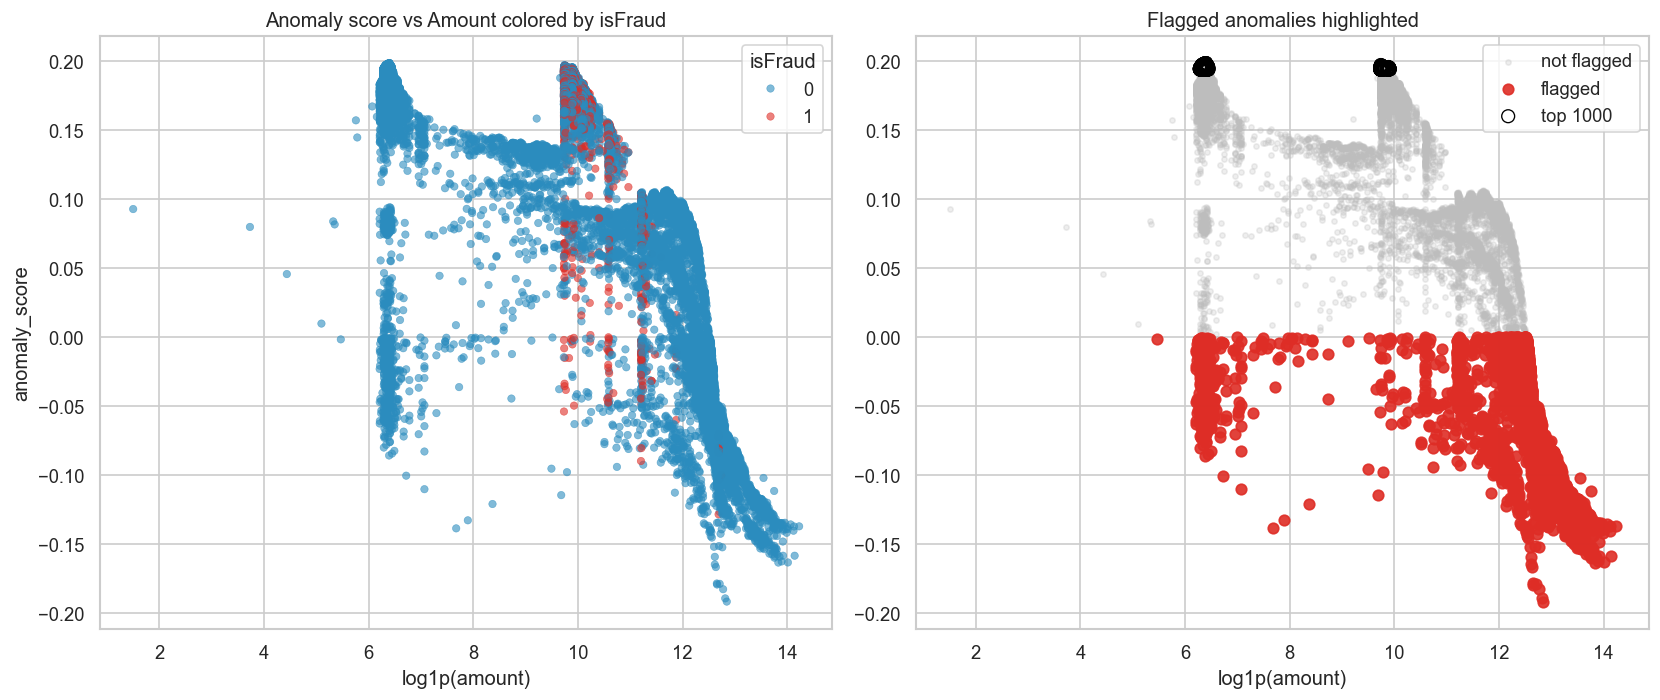

Saved scatter plot to /Users/jonathan/Documents/MSc Data Sci/Year 1/Semester 2/Big Data Analytics/Assignment/anomalous_transaction_detection_msds/notebooks/anomaly_scatter.png


In [9]:
# Scatter visualization integrated with your pipeline
# Run this cell in the same notebook after the pipeline cell that computes:
# df_scaled (Spark DataFrame), anomaly_scores (numpy array), anomaly_labels (numpy array)
# and the original isFraud labels were collected as fraud_labels.

import os
import math
import warnings
warnings.filterwarnings("ignore")

# Configuration
MAX_POINTS = 15000            # max points to plot
RANDOM_SEED = 42
OUTPUT_PNG = "anomaly_scatter.png"
TOP_K_MARK = 1000             # mark top-K anomalies on the plot; set to 0 to disable
USE_LOG_AMOUNT = True         # plot log(amount) on x axis for heavy tails

# Ensure plotting libs
try:
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
except Exception:
    import sys
    !{sys.executable} -m pip install --quiet pandas numpy matplotlib seaborn
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

sns.set(style="whitegrid", context="notebook", rc={"figure.dpi": 120})

# --- Step 1: choose columns to collect from Spark for plotting ---
# Prefer amount and a transaction id if available for hover/inspection
candidate_id_cols = ["transactionID", "txId", "id", "nameOrig", "nameDest"]
candidate_amount_cols = ["amount", "txn_amount", "transaction_amount", "amt", "log_amount"]

spark_cols = [c.name for c in df_scaled.schema]
id_col = next((c for c in candidate_id_cols if c in spark_cols), None)
amount_col = next((c for c in candidate_amount_cols if c in spark_cols), None)

# If log_amount exists in df_scaled use it as numeric; otherwise use amount and compute log later
if amount_col is None:
    # fallback to index if no amount-like column
    amount_col = None

# --- Step 2: sample Spark DataFrame to keep plotting responsive ---
# We will sample stratified by anomaly flag if possible to ensure anomalies are visible
has_flag = True  # we have anomaly_labels array, but df_scaled does not yet contain it
n_total = len(anomaly_scores)  # total rows used to train/score
if n_total != df_scaled.count():
    # If counts differ, warn but proceed; alignment may be off
    print("Warning: number of scored rows differs from df_scaled.count(). Proceeding with best-effort alignment.")

# If dataset is small enough, collect all; otherwise sample indices
if n_total <= MAX_POINTS:
    # collect the selected columns in the same order as used to build feat_array
    cols_to_collect = []
    if id_col:
        cols_to_collect.append(id_col)
    if amount_col:
        cols_to_collect.append(amount_col)
    # always collect isFraud if present
    if "isFraud" in spark_cols:
        cols_to_collect.append("isFraud")
    # If no columns selected, collect a single column to preserve order
    if not cols_to_collect:
        cols_to_collect = [spark_cols[0]]
    pdf = df_scaled.select(*cols_to_collect).toPandas()
    # Align lengths: assume same order as feat_array collection
    pdf = pdf.reset_index(drop=True)
    pdf["anomaly_score"] = anomaly_scores
    pdf["anomaly_flag"]  = (anomaly_labels == -1).astype(int)
    if "isFraud" in pdf.columns:
        pdf["isFraud"] = pd.to_numeric(pdf["isFraud"], errors="coerce").fillna(0).astype(int)
else:
    # sample indices to preserve alignment: sample a set of indices and then collect those rows by adding a row_index
    # Add a row index column to Spark DataFrame temporarily for deterministic alignment
    from pyspark.sql import Window
    from pyspark.sql.functions import monotonically_increasing_id, row_number, lit

    # Create a DataFrame with row_index matching the order used earlier
    df_indexed = df_scaled.withColumn("__row_index__", row_number().over(Window.orderBy(monotonically_increasing_id())) - 1)
    # Choose sample indices stratified by anomaly flag using the anomaly_labels array
    rng = np.random.RandomState(RANDOM_SEED)
    all_indices = np.arange(n_total)
    # ensure anomalies are represented: pick up to 30% of MAX_POINTS from anomalies
    anomaly_indices = all_indices[(anomaly_labels == -1)]
    normal_indices  = all_indices[(anomaly_labels != -1)]
    n_anom_sample = min(len(anomaly_indices), int(MAX_POINTS * 0.3))
    n_norm_sample = MAX_POINTS - n_anom_sample
    sampled_anom = rng.choice(anomaly_indices, size=n_anom_sample, replace=False) if n_anom_sample>0 else np.array([], dtype=int)
    sampled_norm = rng.choice(normal_indices, size=min(len(normal_indices), n_norm_sample), replace=False)
    sampled_idx = np.concatenate([sampled_anom, sampled_norm])
    sampled_idx.sort()
    # Build a small DataFrame of indices to join
    idx_df = spark.createDataFrame(pd.DataFrame({"__row_index__": sampled_idx.tolist()}))
    # Collect the selected columns plus __row_index__
    cols_to_collect = ["__row_index__"]
    if id_col:
        cols_to_collect.append(id_col)
    if amount_col:
        cols_to_collect.append(amount_col)
    if "isFraud" in spark_cols:
        cols_to_collect.append("isFraud")
    sampled_sdf = df_indexed.join(idx_df, on="__row_index__", how="inner").select(*cols_to_collect).orderBy("__row_index__")
    pdf = sampled_sdf.toPandas().reset_index(drop=True)
    # Map anomaly arrays into the sampled pdf using the row indices
    pdf["anomaly_score"] = anomaly_scores[sampled_idx]
    pdf["anomaly_flag"]  = (anomaly_labels[sampled_idx] == -1).astype(int)
    if "isFraud" in pdf.columns:
        pdf["isFraud"] = pd.to_numeric(pdf["isFraud"], errors="coerce").fillna(0).astype(int)

# --- Step 3: prepare plotting columns ---
# x axis: amount or log(amount) or row index
if amount_col and amount_col in pdf.columns:
    if USE_LOG_AMOUNT:
        pdf["x_amount"] = np.log1p(pd.to_numeric(pdf[amount_col], errors="coerce").fillna(0.0))
        x_label = "log1p(amount)"
    else:
        pdf["x_amount"] = pd.to_numeric(pdf[amount_col], errors="coerce").fillna(0.0)
        x_label = "amount"
else:
    # fallback to implicit row index
    pdf = pdf.reset_index().rename(columns={"index": "row_index"})
    pdf["x_amount"] = pdf["row_index"]
    x_label = "row_index"

y_col = "anomaly_score"
flag_col = "anomaly_flag"
label_col = "isFraud" if "isFraud" in pdf.columns else None

# --- Step 4: mark top-K anomalies if requested ---
if TOP_K_MARK and TOP_K_MARK > 0:
    # top by anomaly_score descending (higher score = more anomalous if you negated earlier)
    # In your pipeline anomaly_scores were decision_function; you negated earlier in other code.
    # Here we assume higher anomaly_score means more anomalous. If not, invert accordingly.
    pdf["rank_score"] = pdf[y_col].rank(method="first", ascending=False)
    pdf["topk"] = (pdf["rank_score"] <= TOP_K_MARK).astype(int)
else:
    pdf["topk"] = 0

# --- Step 5: plotting ---
plt.figure(figsize=(14, 6))

# Left panel: colored by known fraud if available, otherwise by flagged
ax1 = plt.subplot(1, 2, 1)
if label_col:
    sns.scatterplot(data=pdf, x="x_amount", y=y_col, hue=label_col,
                    palette={0: "#2b8cbe", 1: "#de2d26"}, alpha=0.6, s=20, ax=ax1, edgecolor=None)
    ax1.legend(title="isFraud", loc="best")
    ax1.set_title("Anomaly score vs Amount colored by isFraud")
else:
    sns.scatterplot(data=pdf, x="x_amount", y=y_col, hue=flag_col,
                    palette={0: "#7f7f7f", 1: "#de2d26"}, alpha=0.6, s=20, ax=ax1, edgecolor=None)
    ax1.legend(title="is_anomaly", loc="best")
    ax1.set_title("Anomaly score vs Amount colored by is_anomaly")

ax1.set_xlabel(x_label)
ax1.set_ylabel("anomaly_score")

# Right panel: highlight flagged anomalies and top-K
ax2 = plt.subplot(1, 2, 2, sharey=ax1)
non_flag = pdf[pdf[flag_col] == 0]
flag = pdf[pdf[flag_col] == 1]
ax2.scatter(non_flag["x_amount"], non_flag[y_col], s=10, alpha=0.25, color="#bdbdbd", label="not flagged")
ax2.scatter(flag["x_amount"], flag[y_col], s=40, alpha=0.9, color="#de2d26", label="flagged")
# overlay top-K with black edge
topk = pdf[pdf["topk"] == 1]
if not topk.empty:
    ax2.scatter(topk["x_amount"], topk[y_col], s=60, facecolors="none", edgecolors="#000000", linewidths=0.8, label=f"top {TOP_K_MARK}")
ax2.legend(loc="best")
ax2.set_xlabel(x_label)
ax2.set_title("Flagged anomalies highlighted")

plt.tight_layout()
plt.savefig(OUTPUT_PNG, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved scatter plot to {os.path.abspath(OUTPUT_PNG)}")
